In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
from scipy import stats

In [2]:
metrics_csv_path = Path("/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/part2_outputs/part2_hypothesis_metrics_long.csv")
output_dir = Path("./part2_inferential_analysis_outputs")

output_dir.mkdir(parents=True, exist_ok=True)
fig_dir = output_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

print("Metrics CSV:", metrics_csv_path.resolve())
print("Output directory:", output_dir.resolve())

Metrics CSV: /data/storage-occ-v2/repos/monte-carlo-selection/results/part2_outputs/part2_hypothesis_metrics_long.csv
Output directory: /data/storage-occ-v2/repos/monte-carlo-selection/notebooks/part2_hypothesis_distribution/part2_inferential_analysis_outputs


In [3]:
metrics_df = pd.read_csv(metrics_csv_path)

print("Loaded metrics table shape:", metrics_df.shape)
display(metrics_df.head())

Loaded metrics table shape: (319, 11)


,case_id,model_type,occluder_size,case_base_id,n_clusters,debiased_entropy,max_debiased_mass_prop,top2_debiased_mass_prop,effective_n_hypotheses,sum_mass_debias_nonnegative,mean_cluster_n_shapes
0,ns_cow_202,shape_biased,8,ns_cow_202,10.0,1.948985,0.378319,0.500004,7.021560,7144.782119,25.0
1,ns_cow_202,shape_biased,16,ns_cow_202,10.0,2.287160,0.146591,0.258737,9.846937,2961.343776,25.0
2,ns_cow_202,shape_biased,32,ns_cow_202,10.0,2.251765,0.148855,0.296493,9.504496,4418.757491,25.0
3,ns_cow_202,shape_biased,64,ns_cow_202,10.0,2.219188,0.189145,0.363797,9.199860,4698.274237,25.0
4,ns_cow_202,texture_biased,8,ns_cow_202,10.0,2.302585,0.100035,0.200061,10.000000,1256.818502,25.0


## Data audit

This section checks:
- shape
- columns
- dtypes
- missing values
- duplicate rows
- number of unique cases
- levels of `model_type`
- levels of `occluder_size`

In [4]:
print("Shape:")
print(metrics_df.shape)

print("\nColumns:")
print(list(metrics_df.columns))

print("\nDtypes:")
display(metrics_df.dtypes.to_frame("dtype"))

Shape:
(319, 11)

Columns:
['case_id', 'model_type', 'occluder_size', 'case_base_id', 'n_clusters', 'debiased_entropy', 'max_debiased_mass_prop', 'top2_debiased_mass_prop', 'effective_n_hypotheses', 'sum_mass_debias_nonnegative', 'mean_cluster_n_shapes']

Dtypes:


,dtype
case_id,object
model_type,object
occluder_size,int64
case_base_id,object
n_clusters,float64
debiased_entropy,float64
max_debiased_mass_prop,float64
top2_debiased_mass_prop,float64
effective_n_hypotheses,float64
sum_mass_debias_nonnegative,float64


In [5]:
required_columns = ["case_id", "model_type", "occluder_size", "debiased_entropy"]
missing_required = [col for col in required_columns if col not in metrics_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

analysis_df = metrics_df.copy()

analysis_df = analysis_df.dropna(subset=["case_id", "model_type", "occluder_size", "debiased_entropy"]).copy()

analysis_df["case_id"] = analysis_df["case_id"].astype(str)
analysis_df["model_type"] = analysis_df["model_type"].astype("category")

# Make occluder size an ordered categorical if possible
occluder_levels_sorted = sorted(pd.to_numeric(analysis_df["occluder_size"], errors="coerce").dropna().unique())
if len(occluder_levels_sorted) > 0:
    analysis_df["occluder_size"] = pd.Categorical(
        pd.to_numeric(analysis_df["occluder_size"], errors="coerce"),
        categories=occluder_levels_sorted,
        ordered=True,
    )
else:
    analysis_df["occluder_size"] = analysis_df["occluder_size"].astype("category")

print("Prepared analysis dataframe shape:", analysis_df.shape)
display(analysis_df.head())

Prepared analysis dataframe shape: (319, 11)


,case_id,model_type,occluder_size,case_base_id,n_clusters,debiased_entropy,max_debiased_mass_prop,top2_debiased_mass_prop,effective_n_hypotheses,sum_mass_debias_nonnegative,mean_cluster_n_shapes
0,ns_cow_202,shape_biased,8,ns_cow_202,10.0,1.948985,0.378319,0.500004,7.021560,7144.782119,25.0
1,ns_cow_202,shape_biased,16,ns_cow_202,10.0,2.287160,0.146591,0.258737,9.846937,2961.343776,25.0
2,ns_cow_202,shape_biased,32,ns_cow_202,10.0,2.251765,0.148855,0.296493,9.504496,4418.757491,25.0
3,ns_cow_202,shape_biased,64,ns_cow_202,10.0,2.219188,0.189145,0.363797,9.199860,4698.274237,25.0
4,ns_cow_202,texture_biased,8,ns_cow_202,10.0,2.302585,0.100035,0.200061,10.000000,1256.818502,25.0


## Check coverage and pairing structure

This section inspects whether cases are observed across both model types and across occluder sizes.

In [6]:
coverage_df = (
    analysis_df
    .groupby(["case_id", "occluder_size"], dropna=False)["model_type"]
    .nunique()
    .rename("n_model_types_present")
    .reset_index()
)

display(coverage_df.head(20))

print("Counts of how many model types are present per case × size:")
display(coverage_df["n_model_types_present"].value_counts().sort_index().rename_axis("n_model_types_present").to_frame("n_case_size_rows"))

/data/storage-occ-v2/pip-tmp/ipykernel_11127/770048192.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df


,case_id,occluder_size,n_model_types_present
0,ns_cow_202,8,2
1,ns_cow_202,16,2
2,ns_cow_202,32,2
3,ns_cow_202,64,2
4,ns_cow_205,8,2
5,ns_cow_205,16,2
6,ns_cow_205,32,2
7,ns_cow_205,64,2
8,ns_cow_350,8,2
9,ns_cow_350,16,2


Counts of how many model types are present per case × size:


,n_case_size_rows
n_model_types_present,
1,1
2,159


## Descriptive summaries

This section computes grouped summaries of `debiased_entropy` by:
- `model_type`
- `occluder_size`
- `model_type × occluder_size`

In [7]:
summary_by_model = (
    analysis_df
    .groupby("model_type", dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

summary_by_occluder = (
    analysis_df
    .groupby("occluder_size", dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

summary_by_model_occluder = (
    analysis_df
    .groupby(["model_type", "occluder_size"], dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

display(summary_by_model)
display(summary_by_occluder)
display(summary_by_model_occluder)

/data/storage-occ-v2/pip-tmp/ipykernel_11127/3904417155.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df
/data/storage-occ-v2/pip-tmp/ipykernel_11127/3904417155.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df
/data/storage-occ-v2/pip-tmp/ipykernel_11127/3904417155.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df


,model_type,count,mean,std,median,min,max
0,shape_biased,160,2.226820,0.107353,2.260079,1.543134,2.302585
1,texture_biased,159,2.257375,0.100272,2.294818,1.332828,2.302585


,occluder_size,count,mean,std,median,min,max
0,8,79,2.255872,0.133177,2.302574,1.332828,2.302585
1,16,80,2.251705,0.076329,2.280448,1.922433,2.302585
2,32,80,2.241049,0.088600,2.270162,1.697804,2.302585
3,64,80,2.219745,0.110764,2.252668,1.543134,2.302585


,model_type,occluder_size,count,mean,std,median,min,max
0,shape_biased,8,40,2.249617,0.093860,2.280653,1.833812,2.302585
1,shape_biased,16,40,2.230579,0.086844,2.257290,1.922433,2.302585
2,shape_biased,32,40,2.224797,0.104970,2.255669,1.697804,2.302329
3,shape_biased,64,40,2.202289,0.135816,2.247688,1.543134,2.296915
4,texture_biased,8,39,2.262289,0.165169,2.302585,1.332828,2.302585
5,texture_biased,16,40,2.272831,0.057829,2.298062,2.059876,2.302585
6,texture_biased,32,40,2.257301,0.065884,2.283087,1.975082,2.302585
7,texture_biased,64,40,2.237202,0.076032,2.253854,1.987655,2.302585


## Descriptive plot 1. Mean `debiased_entropy` across occluder size

Separate lines are drawn for each model type.

/data/storage-occ-v2/pip-tmp/ipykernel_11127/2586896804.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df
/data/storage-occ-v2/pip-tmp/ipykernel_11127/2586896804.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_type, df_sub in plot_df.groupby("model_type"):


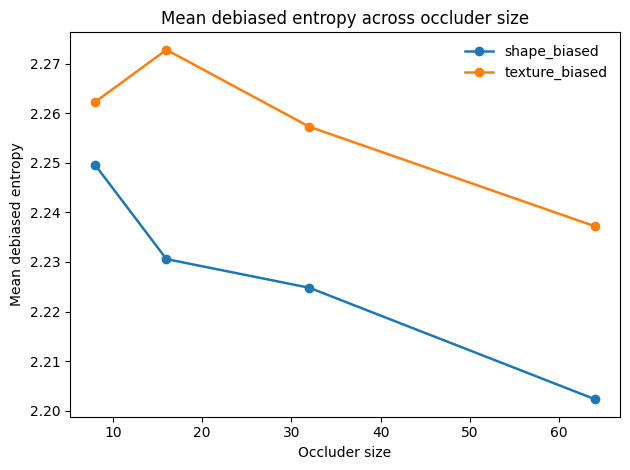

In [8]:
plot_df = (
    analysis_df
    .groupby(["model_type", "occluder_size"], dropna=False)["debiased_entropy"]
    .mean()
    .reset_index()
)

plot_df["occluder_size_num"] = pd.to_numeric(plot_df["occluder_size"], errors="coerce")

fig, ax = plt.subplots()

for model_type, df_sub in plot_df.groupby("model_type"):
    df_sub = df_sub.sort_values("occluder_size_num")
    ax.plot(
        df_sub["occluder_size_num"],
        df_sub["debiased_entropy"],
        marker="o",
        linewidth=1.8,
        label=str(model_type),
    )

ax.set_xlabel("Occluder size")
ax.set_ylabel("Mean debiased entropy")
ax.set_title("Mean debiased entropy across occluder size")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "mean_debiased_entropy_across_occluder_size.png", bbox_inches="tight")
plt.show()

In [9]:
summary_by_model = (
    analysis_df
    .groupby("model_type", dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

summary_by_occluder = (
    analysis_df
    .groupby("occluder_size", dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

summary_by_model_occluder = (
    analysis_df
    .groupby(["model_type", "occluder_size"], dropna=False)["debiased_entropy"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .reset_index()
)

summary_by_model_occluder["sem"] = (
    summary_by_model_occluder["std"] / np.sqrt(summary_by_model_occluder["count"])
)

display(summary_by_model)
display(summary_by_occluder)
display(summary_by_model_occluder)

/data/storage-occ-v2/pip-tmp/ipykernel_11127/2299105569.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df
/data/storage-occ-v2/pip-tmp/ipykernel_11127/2299105569.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df
/data/storage-occ-v2/pip-tmp/ipykernel_11127/2299105569.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df


,model_type,count,mean,std,median,min,max
0,shape_biased,160,2.226820,0.107353,2.260079,1.543134,2.302585
1,texture_biased,159,2.257375,0.100272,2.294818,1.332828,2.302585


,occluder_size,count,mean,std,median,min,max
0,8,79,2.255872,0.133177,2.302574,1.332828,2.302585
1,16,80,2.251705,0.076329,2.280448,1.922433,2.302585
2,32,80,2.241049,0.088600,2.270162,1.697804,2.302585
3,64,80,2.219745,0.110764,2.252668,1.543134,2.302585


,model_type,occluder_size,count,mean,std,median,min,max,sem
0,shape_biased,8,40,2.249617,0.093860,2.280653,1.833812,2.302585,0.014841
1,shape_biased,16,40,2.230579,0.086844,2.257290,1.922433,2.302585,0.013731
2,shape_biased,32,40,2.224797,0.104970,2.255669,1.697804,2.302329,0.016597
3,shape_biased,64,40,2.202289,0.135816,2.247688,1.543134,2.296915,0.021474
4,texture_biased,8,39,2.262289,0.165169,2.302585,1.332828,2.302585,0.026448
5,texture_biased,16,40,2.272831,0.057829,2.298062,2.059876,2.302585,0.009144
6,texture_biased,32,40,2.257301,0.065884,2.283087,1.975082,2.302585,0.010417
7,texture_biased,64,40,2.237202,0.076032,2.253854,1.987655,2.302585,0.012022


/data/storage-occ-v2/pip-tmp/ipykernel_11127/343825773.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for model_type, df_sub in plot_df.groupby("model_type"):


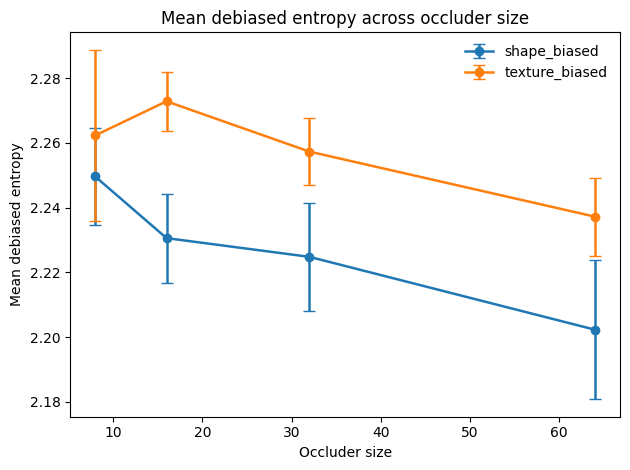

In [10]:
plot_df = summary_by_model_occluder.copy()
plot_df["occluder_size_num"] = pd.to_numeric(plot_df["occluder_size"], errors="coerce")

fig, ax = plt.subplots()

for model_type, df_sub in plot_df.groupby("model_type"):
    df_sub = df_sub.sort_values("occluder_size_num")
    ax.errorbar(
        df_sub["occluder_size_num"],
        df_sub["mean"],
        yerr=df_sub["sem"],
        marker="o",
        linewidth=1.8,
        capsize=4,
        label=str(model_type),
    )

ax.set_xlabel("Occluder size")
ax.set_ylabel("Mean debiased entropy")
ax.set_title("Mean debiased entropy across occluder size")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "mean_debiased_entropy_across_occluder_size.png", bbox_inches="tight")
plt.show()

NameError: name 'FIG_DIR' is not defined

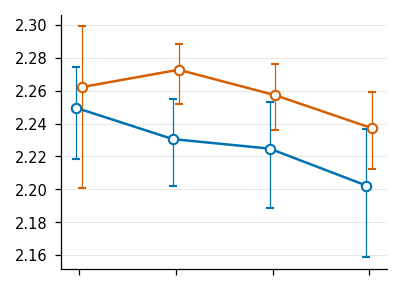

In [ ]:
import figstyle
from figstyle import MODEL_COLORS
figstyle.apply()

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- 0. Category levels ----------
size_levels = sorted(analysis_df["occluder_size"].unique())
model_levels = sorted(analysis_df["model_type"].unique())

# Robust color lookup: normalize keys so "Shape-Biased", "shape_biased",
# "shape-biased" all resolve to the same MODEL_COLORS entry.
def resolve_color(model):
    key = str(model).lower().replace("-", "_").replace(" ", "_")
    return MODEL_COLORS[key]

# ---------- 1. Aggregate with bootstrap CI ----------
def bootstrap_ci(x, n_boot=2000, ci=95, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    x = np.asarray(x)
    if len(x) < 2:
        return (np.nan, np.nan)
    boots = rng.choice(x, size=(n_boot, len(x)), replace=True).mean(axis=1)
    lo, hi = np.percentile(boots, [(100 - ci) / 2, 100 - (100 - ci) / 2])
    return lo, hi

agg = (
    analysis_df
    .groupby(["occluder_size", "model_type"], observed=True)["debiased_entropy"]
    .agg(mean="mean", ci=lambda s: bootstrap_ci(s.values))
    .reset_index()
)
agg[["ci_lo", "ci_hi"]] = pd.DataFrame(agg["ci"].tolist(), index=agg.index)
agg["err_lo"] = agg["mean"] - agg["ci_lo"]
agg["err_hi"] = agg["ci_hi"] - agg["mean"]

# ---------- 2. Plot ----------
# Slightly taller than Fig 1 because the y-range is compressed
fig, ax = plt.subplots(figsize=(2.8, 2.2))

x_positions = np.arange(len(size_levels))
jitter = 0.06   # small horizontal offset so error bars don't overlap

for i, model in enumerate(model_levels):
    s = (agg[agg["model_type"] == model]
         .set_index("occluder_size")
         .reindex(size_levels)
         .reset_index())

    offset = (i - (len(model_levels) - 1) / 2) * jitter
    xs = x_positions + offset

    ax.errorbar(
        xs,
        s["mean"],
        yerr=[s["err_lo"], s["err_hi"]],
        color=resolve_color(model),
        linestyle="-",
        marker="o",
        markerfacecolor="white",
        markeredgewidth=1.0,
        capsize=2,
        elinewidth=0.6,
        capthick=0.6,
        label=model,
    )

# Geometry-only; labels/legend rebuilt in Illustrator
ax.set_xticks(x_positions)
ax.set_xticklabels([""] * len(x_positions))
ax.set_xlabel("")
ax.set_ylabel("")

ax.yaxis.grid(True, linewidth=0.4, alpha=0.35)
ax.set_axisbelow(True)

# ---------- 3. Export ----------
stem = "fig02_debiased_entropy_by_occluder_size"
fig.savefig(fig_dir / f"{stem}.svg")
fig.savefig(fig_dir / f"{stem}.pdf")
plt.show()

## Descriptive plot 2. Distribution of `debiased_entropy` by model type within occluder size

Separate boxplots are drawn for each occluder size using matplotlib only.

/data/storage-occ-v2/pip-tmp/ipykernel_12297/1564686876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in model_levels])
/data/storage-occ-v2/pip-tmp/ipykernel_12297/1564686876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in model_levels])
/data/storage-occ-v2/pip-tmp/ipykernel_12297/1564686876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[str(m) for m in model_levels])
/data/storage-occ-v2/pip-tmp/ipykernel_12297/1564686876.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() h

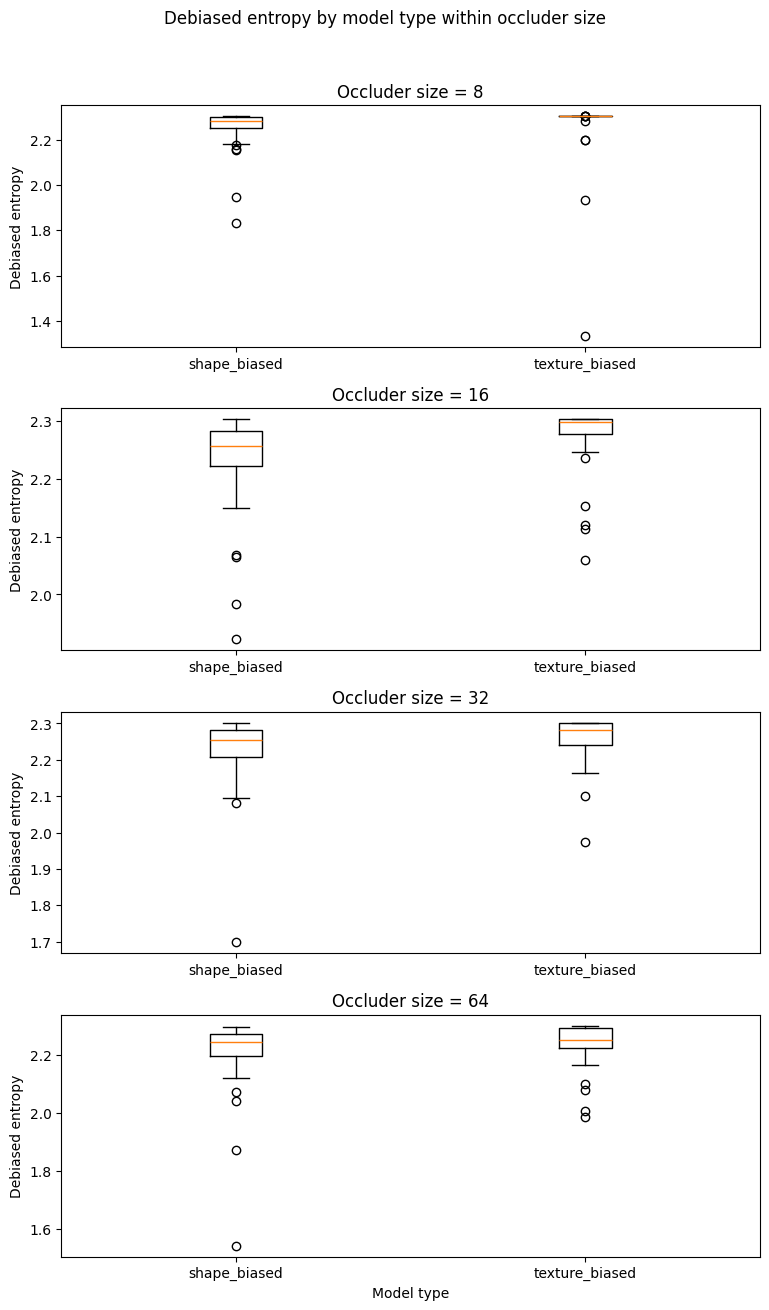

In [ ]:
occluder_levels = list(analysis_df["occluder_size"].cat.categories)
model_levels = list(analysis_df["model_type"].cat.categories)

n_panels = len(occluder_levels)
fig, axes = plt.subplots(n_panels, 1, figsize=(7.8, max(4, 3.2 * n_panels)), squeeze=False)

for ax, occ in zip(axes.flatten(), occluder_levels):
    sub = analysis_df.loc[analysis_df["occluder_size"] == occ].copy()

    data = [
        sub.loc[sub["model_type"] == model, "debiased_entropy"].dropna().to_numpy()
        for model in model_levels
    ]

    ax.boxplot(data, labels=[str(m) for m in model_levels])
    ax.set_title(f"Occluder size = {occ}")
    ax.set_ylabel("Debiased entropy")

axes[-1, 0].set_xlabel("Model type")
fig.suptitle("Debiased entropy by model type within occluder size", y=1.02)
fig.tight_layout()

fig.savefig(fig_dir / "debiased_entropy_boxplots_by_occluder_size.png", bbox_inches="tight")
plt.show()

## Confirmatory Part II mixed model

This block fits the confirmatory mixed model:

`debiased_entropy ~ model_type * occluder_size`

with a random intercept for `case_id`.

## Diagnose the design before fitting the mixed model

This block checks whether all combinations of `model_type` and `occluder_size` are present and whether cases are sufficiently repeated across conditions for a mixed model with random intercepts for `case_id`.

In [ ]:
# Basic cell counts
design_counts = (
    analysis_df
    .groupby(["model_type", "occluder_size"], dropna=False)
    .size()
    .rename("n_rows")
    .reset_index()
)

display(design_counts)

# Number of observations per case
case_counts = (
    analysis_df["case_id"]
    .value_counts()
    .rename_axis("case_id")
    .reset_index(name="n_rows_for_case")
)

display(case_counts.head(20))
print("Distribution of rows per case:")
display(case_counts["n_rows_for_case"].value_counts().sort_index().rename_axis("rows_per_case").to_frame("n_cases"))

# Coverage table: how many model_type x size cells does each case have?
coverage = (
    analysis_df
    .assign(cell=lambda d: d["model_type"].astype(str) + "__size_" + d["occluder_size"].astype(str))
    .groupby("case_id")["cell"]
    .nunique()
    .rename("n_unique_cells")
    .reset_index()
)

display(coverage.head(20))
print("Distribution of number of cells per case:")
display(coverage["n_unique_cells"].value_counts().sort_index().rename_axis("n_unique_cells").to_frame("n_cases"))

/data/storage-occ-v2/pip-tmp/ipykernel_12297/2149984161.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analysis_df


,model_type,occluder_size,n_rows
0,shape_biased,8,40
1,shape_biased,16,40
2,shape_biased,32,40
3,shape_biased,64,40
4,texture_biased,8,39
5,texture_biased,16,40
6,texture_biased,32,40
7,texture_biased,64,40


,case_id,n_rows_for_case
0,ns_cow_202,8
1,ns_cow_205,8
2,ns_cow_350,8
3,ns_cow_510,8
4,ns_cow_780,8
5,ns_dog_105,8
6,ns_dog_214,8
7,ns_dog_350,8
8,ns_dog_69,8
9,ns_elephant_100,8


Distribution of rows per case:


,n_cases
rows_per_case,
7,1
8,39


,case_id,n_unique_cells
0,ns_cow_202,8
1,ns_cow_205,8
2,ns_cow_350,8
3,ns_cow_510,8
4,ns_cow_780,8
5,ns_dog_105,8
6,ns_dog_214,8
7,ns_dog_350,8
8,ns_dog_69,8
9,ns_dog_780,7


Distribution of number of cells per case:


,n_cases
n_unique_cells,
7,1
8,39


## Restrict to cases with complete repeated-measures coverage

For the confirmatory mixed model, it is safest to use only cases that are observed in every `model_type × occluder_size` combination present in the dataset.

In [ ]:
# Determine how many cells should exist in a complete case
n_model_levels = analysis_df["model_type"].nunique()
n_size_levels = analysis_df["occluder_size"].nunique()
n_expected_cells = n_model_levels * n_size_levels

complete_case_ids = coverage.loc[
    coverage["n_unique_cells"] == n_expected_cells, "case_id"
].tolist()

analysis_complete_df = analysis_df.loc[
    analysis_df["case_id"].isin(complete_case_ids)
].copy()

print("Expected cells per complete case:", n_expected_cells)
print("Number of complete cases:", len(complete_case_ids))
print("Shape of restricted analysis dataframe:", analysis_complete_df.shape)

display(
    analysis_complete_df
    .groupby(["model_type", "occluder_size"])
    .size()
    .rename("n_rows")
    .reset_index()
)

Expected cells per complete case: 8
Number of complete cases: 39
Shape of restricted analysis dataframe: (312, 11)


/data/storage-occ-v2/pip-tmp/ipykernel_12297/1729514265.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["model_type", "occluder_size"])


,model_type,occluder_size,n_rows
0,shape_biased,8,39
1,shape_biased,16,39
2,shape_biased,32,39
3,shape_biased,64,39
4,texture_biased,8,39
5,texture_biased,16,39
6,texture_biased,32,39
7,texture_biased,64,39


## Fit the confirmatory mixed model on the complete-case dataset

This first attempts the preregistered mixed model on the complete repeated-measures subset.

In [ ]:
ols_formula = "debiased_entropy ~ C(case_id) + C(model_type) * C(occluder_size)"
ols_result = smf.ols(ols_formula, data=analysis_complete_df).fit()

print(ols_result.summary())

                            OLS Regression Results                            
Dep. Variable:       debiased_entropy   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     1.320
Date:                Wed, 15 Apr 2026   Prob (F-statistic):             0.0951
Time:                        04:25:11   Log-Likelihood:                 290.12
No. Observations:                 312   AIC:                            -488.2
Df Residuals:                     266   BIC:                            -316.1
Df Model:                          45                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [ ]:
ols_fixed_effects_table = pd.DataFrame({
    "term": ols_result.params.index,
    "estimate": ols_result.params.values,
    "std_error": ols_result.bse.values,
    "t_value": ols_result.tvalues.values,
    "p_value": ols_result.pvalues.values,
})

display(
    ols_fixed_effects_table.loc[
        ols_fixed_effects_table["term"].str.contains("model_type|occluder_size|Intercept", regex=True, na=False)
    ].reset_index(drop=True)
)

,term,estimate,std_error,t_value,p_value
0,Intercept,2.234933,0.039707,56.285901,8.965068e-150
1,C(model_type)[T.texture_biased],0.013998,0.023418,0.597748,5.505167e-01
2,C(occluder_size)[T.16],-0.019029,0.023418,-0.812579,4.171863e-01
3,C(occluder_size)[T.32],-0.024283,0.023418,-1.036930,3.007102e-01
4,C(occluder_size)[T.64],-0.047858,0.023418,-2.043642,4.197403e-02
5,C(model_type)[T.texture_biased]:C(occluder_siz...,0.029129,0.033118,0.879567,3.798878e-01
6,C(model_type)[T.texture_biased]:C(occluder_siz...,0.018244,0.033118,0.550886,5.821743e-01
7,C(model_type)[T.texture_biased]:C(occluder_siz...,0.021113,0.033118,0.637500,5.243475e-01


In [ ]:
# Assumption checks for the repeated-measures ANOVA
#
# Mirrors the data preparation in the next cell:
#   subject       = case_id
#   within        = [model_type, occluder_size]
#   DV            = debiased_entropy
#   complete cases only (all model_type x occluder_size cells present).
#
# Assumptions assessed and saved for thesis reporting:
#   1. Normality of the DV within each within-subject cell (Shapiro-Wilk)
#      and on cell-mean residuals (Shapiro / D'Agostino).
#   2. Homogeneity of variance across cells (Levene, median-centred).
#   3. Sphericity per within-subject factor with >2 levels (Mauchly's W
#      plus Greenhouse-Geisser, Huynh-Feldt and lower-bound epsilon).
#      Factors with exactly 2 levels satisfy sphericity by design.
#   4. Extreme outliers (|z| > 3 within each cell).
#
# Note: statsmodels AnovaRM does not apply sphericity corrections; quote
# the epsilon values from this cell to justify a GG correction in the
# thesis if Mauchly's test is significant.

import json as _json
from scipy import stats

# Aggregate to one observation per case_id x cell so the checks match the
# repeated-measures unit (and we don't conflate within-cell replication
# variance with subject-by-condition variance).
_assum_src = analysis_df.copy()
_assum_src["model_type"] = _assum_src["model_type"].astype(str)
_assum_src["occluder_size"] = _assum_src["occluder_size"].astype(str)

within_factors_p2 = ["model_type", "occluder_size"]

assum_df = (
    _assum_src
    .groupby(["case_id"] + within_factors_p2, observed=True, as_index=False)["debiased_entropy"]
    .mean()
)

_n_levels = {c: int(assum_df[c].nunique()) for c in within_factors_p2}
_expected_cells = int(np.prod(list(_n_levels.values())))

_case_cells = (
    assum_df.groupby("case_id", observed=True)
    .size()
    .reset_index(name="n_cells")
)
_complete_ids = _case_cells.loc[
    _case_cells["n_cells"] == _expected_cells, "case_id"
]
assum_df = assum_df[assum_df["case_id"].isin(_complete_ids)].copy()

print("Assumption-check dataset shape:", assum_df.shape)
print("Complete case_id count:", int(assum_df["case_id"].nunique()))
print("Within-factor levels:", _n_levels)
print("Expected cells per case:", _expected_cells)

# Where to save assumption-check artefacts
assum_table_dir = output_dir / "tables"
assum_table_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------
# 1. Per-cell normality (Shapiro-Wilk) + residual-level normality
# -----------------------------------------------------------------------
normality_rows = []
for keys, sub in assum_df.groupby(within_factors_p2, observed=True):
    vals = sub["debiased_entropy"].to_numpy()
    n = len(vals)
    if n >= 3 and np.std(vals) > 0:
        W, p = stats.shapiro(vals)
    else:
        W, p = np.nan, np.nan
    row = dict(zip(within_factors_p2, keys if isinstance(keys, tuple) else (keys,)))
    row.update(dict(
        n=int(n),
        mean=float(np.mean(vals)) if n else np.nan,
        sd=float(np.std(vals, ddof=1)) if n > 1 else np.nan,
        skew=float(stats.skew(vals)) if n > 2 else np.nan,
        kurtosis=float(stats.kurtosis(vals)) if n > 3 else np.nan,
        shapiro_W=float(W) if not np.isnan(W) else np.nan,
        shapiro_p=float(p) if not np.isnan(p) else np.nan,
        normal_at_0p05=(bool(p > 0.05) if not np.isnan(p) else np.nan),
    ))
    normality_rows.append(row)

normality_df = pd.DataFrame(normality_rows)
n_cells_total = len(normality_df)
n_cells_normal = int(normality_df["normal_at_0p05"].fillna(False).sum())
n_cells_nonnormal = n_cells_total - n_cells_normal
print(
    f"\nShapiro-Wilk per cell: {n_cells_normal}/{n_cells_total} "
    f"cells consistent with normality at p>0.05"
)
display(normality_df)

normality_df.to_csv(
    assum_table_dir / "rm_anova_assumption_normality_per_cell.csv", index=False
)

# Residuals = deviations from each cell mean
_cell_means = (
    assum_df.groupby(within_factors_p2, observed=True)["debiased_entropy"]
    .transform("mean")
)
_residuals = assum_df["debiased_entropy"].to_numpy() - _cell_means.to_numpy()
if len(_residuals) <= 5000:
    _res_stat, _res_p = stats.shapiro(_residuals)
    _res_test = "shapiro_wilk"
else:
    _res_stat, _res_p = stats.normaltest(_residuals)
    _res_test = "dagostino_pearson"

residual_summary = {
    "test": _res_test,
    "n_residuals": int(len(_residuals)),
    "statistic": float(_res_stat),
    "p_value": float(_res_p),
    "normal_at_0p05": bool(_res_p > 0.05),
    "residual_skew": float(stats.skew(_residuals)),
    "residual_kurtosis": float(stats.kurtosis(_residuals)),
}
print("\nResidual-level normality:", residual_summary)

# -----------------------------------------------------------------------
# 2. Homogeneity of variance across cells (Levene, median-centred)
# -----------------------------------------------------------------------
_groups = [
    g["debiased_entropy"].to_numpy()
    for _, g in assum_df.groupby(within_factors_p2, observed=True)
    if len(g) >= 2
]
if len(_groups) >= 2:
    _lev_stat, _lev_p = stats.levene(*_groups, center="median")
else:
    _lev_stat, _lev_p = np.nan, np.nan

levene_summary = {
    "test": "levene_brown_forsythe_median",
    "n_groups": int(len(_groups)),
    "statistic": (float(_lev_stat) if not np.isnan(_lev_stat) else np.nan),
    "p_value": (float(_lev_p) if not np.isnan(_lev_p) else np.nan),
    "homogeneous_at_0p05": (
        bool(_lev_p > 0.05) if not np.isnan(_lev_p) else np.nan
    ),
}
print("\nLevene homogeneity of variance:", levene_summary)

# -----------------------------------------------------------------------
# 3. Sphericity (Mauchly) + Greenhouse-Geisser / Huynh-Feldt epsilon
# -----------------------------------------------------------------------
def _orthonormal_contrasts(k):
    """Return a (k x (k-1)) orthonormal (Helmert-style) contrast matrix."""
    M = np.zeros((k, k - 1))
    for j in range(k - 1):
        col = np.zeros(k)
        col[: j + 1] = 1.0 / (j + 1)
        col[j + 1] = -1.0
        col /= np.linalg.norm(col)
        M[:, j] = col
    return M

def _mauchly_and_epsilon(Y):
    """
    Y: (n_subjects, k_levels). Returns Mauchly W, chi2, df, p, and
    Greenhouse-Geisser, Huynh-Feldt, lower-bound epsilon. None if degenerate.
    """
    n, k = Y.shape
    if k < 3 or n <= k:
        return None
    C = _orthonormal_contrasts(k)
    Z = Y @ C
    S = np.atleast_2d(np.cov(Z, rowvar=False, ddof=1))
    eigvals = np.linalg.eigvalsh(S)
    eigvals = eigvals[eigvals > 1e-12]
    if len(eigvals) < (k - 1):
        return None
    det_S = float(np.prod(eigvals))
    tr_S = float(np.sum(eigvals))
    W = det_S / (tr_S / (k - 1)) ** (k - 1)
    df = k * (k - 1) / 2.0 - 1.0
    f_corr = 1 - (2 * (k - 1) ** 2 + (k - 1) + 2) / (6.0 * (k - 1) * (n - 1))
    chi2 = -(n - 1) * f_corr * np.log(max(W, 1e-300))
    p_val = float(1 - stats.chi2.cdf(chi2, df)) if df > 0 else np.nan
    gg = (tr_S ** 2) / ((k - 1) * float(np.sum(eigvals ** 2)))
    hf_num = n * (k - 1) * gg - 2.0
    hf_den = (k - 1) * (n - 1 - (k - 1) * gg)
    hf = min(1.0, hf_num / hf_den) if hf_den > 0 else np.nan
    lb = 1.0 / (k - 1)
    return dict(
        mauchly_W=float(W),
        chi2=float(chi2),
        df=float(df),
        p_value=p_val,
        sphericity_at_0p05=bool(p_val > 0.05) if not np.isnan(p_val) else np.nan,
        gg_epsilon=float(gg),
        hf_epsilon=float(hf),
        lb_epsilon=float(lb),
    )

sphericity_rows = []
for factor in within_factors_p2:
    wide = (
        assum_df.groupby(["case_id", factor], observed=True)["debiased_entropy"]
        .mean()
        .unstack(factor)
        .dropna()
    )
    levels = list(wide.columns)
    k = len(levels)
    row = {
        "factor": factor,
        "k_levels": int(k),
        "n_subjects": int(wide.shape[0]),
        "levels": ",".join(map(str, levels)),
    }
    if k <= 2:
        row.update(dict(
            mauchly_W=np.nan, chi2=np.nan, df=np.nan, p_value=np.nan,
            sphericity_at_0p05=True,
            gg_epsilon=1.0, hf_epsilon=1.0, lb_epsilon=1.0,
            note="sphericity_trivial_k<=2",
        ))
    else:
        res = _mauchly_and_epsilon(wide.to_numpy())
        if res is None:
            row.update(dict(
                mauchly_W=np.nan, chi2=np.nan, df=np.nan, p_value=np.nan,
                sphericity_at_0p05=np.nan,
                gg_epsilon=np.nan, hf_epsilon=np.nan, lb_epsilon=np.nan,
                note="insufficient_data_or_singular",
            ))
        else:
            res["note"] = "ok"
            row.update(res)
    sphericity_rows.append(row)

sphericity_df = pd.DataFrame(sphericity_rows)
print("\nSphericity per within-subject factor (marginal):")
display(sphericity_df)

sphericity_df.to_csv(
    assum_table_dir / "rm_anova_assumption_sphericity.csv", index=False
)

# -----------------------------------------------------------------------
# 4. Extreme outliers (|z| > 3 within each cell)
# -----------------------------------------------------------------------
assum_df["_cell_z"] = (
    assum_df.groupby(within_factors_p2, observed=True)["debiased_entropy"]
    .transform(
        lambda v: (v - v.mean()) / v.std(ddof=1)
        if v.std(ddof=1) and not np.isnan(v.std(ddof=1)) else np.nan
    )
)
assum_df["_is_outlier"] = assum_df["_cell_z"].abs() > 3.0

outliers_df = assum_df[assum_df["_is_outlier"]].copy()
outliers_summary = {
    "n_observations": int(len(assum_df)),
    "n_outliers_abs_z_gt_3": int(len(outliers_df)),
    "pct_outliers": (
        float(100 * len(outliers_df) / len(assum_df)) if len(assum_df) else np.nan
    ),
    "n_cases_with_any_outlier": (
        int(outliers_df["case_id"].nunique()) if len(outliers_df) else 0
    ),
}
print("\nOutliers (|z|>3 within cell):", outliers_summary)

outliers_df.drop(columns=["_is_outlier"]).to_csv(
    assum_table_dir / "rm_anova_assumption_outliers.csv", index=False
)

# -----------------------------------------------------------------------
# Compact thesis-ready summary table
# -----------------------------------------------------------------------
thesis_rows = []
thesis_rows.append({
    "assumption": "normality_per_cell_shapiro",
    "summary": f"{n_cells_normal}/{n_cells_total} cells with p>0.05",
    "verdict": (
        "met_in_majority"
        if n_cells_total and n_cells_normal / n_cells_total >= 0.8
        else "violated"
    ),
    "detail_file": "rm_anova_assumption_normality_per_cell.csv",
})
thesis_rows.append({
    "assumption": "normality_of_residuals",
    "summary": (
        f"{residual_summary['test']} stat={residual_summary['statistic']:.3f}, "
        f"p={residual_summary['p_value']:.3g}, "
        f"skew={residual_summary['residual_skew']:.2f}, "
        f"kurt={residual_summary['residual_kurtosis']:.2f}"
    ),
    "verdict": "met" if residual_summary["normal_at_0p05"] else "violated",
    "detail_file": "",
})
thesis_rows.append({
    "assumption": "homogeneity_of_variance_levene",
    "summary": (
        f"W={levene_summary['statistic']:.3f}, "
        f"p={levene_summary['p_value']:.3g} (k={levene_summary['n_groups']})"
    ),
    "verdict": "met" if levene_summary["homogeneous_at_0p05"] else "violated",
    "detail_file": "",
})
for r in sphericity_rows:
    if r["k_levels"] <= 2:
        thesis_rows.append({
            "assumption": f"sphericity_{r['factor']}",
            "summary": f"k={r['k_levels']} (sphericity not applicable)",
            "verdict": "met_by_design",
            "detail_file": "rm_anova_assumption_sphericity.csv",
        })
    elif pd.isna(r.get("p_value", np.nan)):
        thesis_rows.append({
            "assumption": f"sphericity_{r['factor']}",
            "summary": "insufficient data or singular covariance",
            "verdict": "undetermined",
            "detail_file": "rm_anova_assumption_sphericity.csv",
        })
    else:
        verdict = "met" if r["sphericity_at_0p05"] else "violated_use_GG_correction"
        thesis_rows.append({
            "assumption": f"sphericity_{r['factor']}",
            "summary": (
                f"Mauchly W={r['mauchly_W']:.3f}, chi2={r['chi2']:.2f}, "
                f"df={r['df']:.0f}, p={r['p_value']:.3g}; "
                f"GG eps={r['gg_epsilon']:.3f}, HF eps={r['hf_epsilon']:.3f}"
            ),
            "verdict": verdict,
            "detail_file": "rm_anova_assumption_sphericity.csv",
        })
thesis_rows.append({
    "assumption": "no_extreme_outliers_abs_z_gt_3",
    "summary": (
        f"{outliers_summary['n_outliers_abs_z_gt_3']} / "
        f"{outliers_summary['n_observations']} obs "
        f"({outliers_summary['pct_outliers']:.2f}%) across "
        f"{outliers_summary['n_cases_with_any_outlier']} cases"
    ),
    "verdict": (
        "no_extreme_outliers"
        if outliers_summary["n_outliers_abs_z_gt_3"] == 0
        else "inspect"
    ),
    "detail_file": "rm_anova_assumption_outliers.csv",
})

assumption_summary_df = pd.DataFrame(thesis_rows)
display(assumption_summary_df)

assumption_summary_df.to_csv(
    assum_table_dir / "rm_anova_assumption_summary.csv", index=False
)

# Full manifest
assumption_manifest = {
    "analysis": "part2_rm_anova_assumption_checks",
    "depvar": "debiased_entropy",
    "subject": "case_id",
    "within_factors": within_factors_p2,
    "dataset_rows": int(len(assum_df)),
    "n_complete_subjects": int(assum_df["case_id"].nunique()),
    "within_factor_levels": _n_levels,
    "expected_cells_per_subject": _expected_cells,
    "normality_per_cell": {
        "test": "shapiro_wilk",
        "n_cells_total": int(n_cells_total),
        "n_cells_normal_p_gt_0p05": int(n_cells_normal),
        "n_cells_nonnormal": int(n_cells_nonnormal),
    },
    "normality_residuals": residual_summary,
    "homogeneity_levene": levene_summary,
    "sphericity": {
        r["factor"]: {k: v for k, v in r.items() if k != "factor"}
        for r in sphericity_rows
    },
    "outliers": outliers_summary,
}

with open(assum_table_dir / "rm_anova_assumption_manifest.json", "w") as f:
    _json.dump(assumption_manifest, f, indent=2, default=str)

print("\nAssumption-check outputs saved to:", assum_table_dir.resolve())
for fn in [
    "rm_anova_assumption_normality_per_cell.csv",
    "rm_anova_assumption_sphericity.csv",
    "rm_anova_assumption_outliers.csv",
    "rm_anova_assumption_summary.csv",
    "rm_anova_assumption_manifest.json",
]:
    print(" -", fn)


In [ ]:
from statsmodels.stats.anova import AnovaRM

# Keep only complete cases across all model_type x occluder_size cells
analysis_df = analysis_df.copy()

analysis_df["cell"] = (
    analysis_df["model_type"].astype(str) + "__" + analysis_df["occluder_size"].astype(str)
)

coverage = (
    analysis_df.groupby("case_id")["cell"]
    .nunique()
    .reset_index(name="n_cells")
)

n_expected_cells = (
    analysis_df["model_type"].nunique() * analysis_df["occluder_size"].nunique()
)

complete_case_ids = coverage.loc[coverage["n_cells"] == n_expected_cells, "case_id"]

anova_df = analysis_df.loc[analysis_df["case_id"].isin(complete_case_ids)].copy()

anova = AnovaRM(
    data=anova_df,
    depvar="debiased_entropy",
    subject="case_id",
    within=["model_type", "occluder_size"],
).fit()

print(anova)

                         Anova
                         F Value Num DF  Den DF  Pr > F
-------------------------------------------------------
model_type                6.7210 1.0000  38.0000 0.0135
occluder_size             1.9891 3.0000 114.0000 0.1196
model_type:occluder_size  0.2856 3.0000 114.0000 0.8357

